# **Analisis Eda del proyecto**


## *Contexto y objetivos*

La tasa de natalidad ha disminuido en los últimos años en varios países, mientras que en otros esta tasa de natalidad aún se mantiene alta. Estos cambios llegan a ser un gran indicador para poder comprender el desarrollo económico y social de un país.

Analizar las causas de estos cambios es clave para entender fenómenos como el envejecimiento poblacional, la migración o el crecimiento económico. Este proyecto busca ver cómo distintas variables (como el nivel educativo, acceso a  salud, urbanización, etc.) se relacionan con la tasa de natalidad. Queremos explorar con datos desde 1965 hasta 2010 que correlacion tienen estas distintas variables con el aumento o disminucion en la tasa de natalidad.

### _Referencias_:
- https://www.bbc.com/mundo/noticias-53417504
- https://theconversation.com/se-esta-produciendo-un-colapso-demografico-mundial-234291

## Recordamos las preguntas de investigacion:

1) ¿Existe relación entre el nivel de urbanización y las tasas de natalidad?  
  
2) ¿Existen patrones regionales o socioeconómicos que expliquen diferencias en natalidad? 
  
3) ¿Puede predecirse la tasa de natalidad de un país en base a sus condiciones socioeconómicas? 
  
4) ¿Qué  países  se  comportan  como  outliers  (tienen  tasas  de  natalidad  inusuales  dadas  sus 
características)? 
  
5) ¿Cómo  han  cambiado  las  tasas  de  natalidad  en  las  últimas  décadas,  y  qué  variables  se 
relacionan con esos cambios? 

In [58]:
# Librerias a importar
from bs4 import BeautifulSoup
import requests
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import json
import time
from os import path
#para adaptar los datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#Modelos de machineaprender
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor

# Datos

Vamos a ocupar principalmente datos publicos del **Banco Mundial**, ademas de los siguientes datos:

#### Apis a utilizar:
- Banco Mundial (https://data.worldbank.org)  
- Our World in Data (https://ourworldindata.org)  
- World Meter (https://worldometer.readthedocs.io/en/latest)  
- Datos Macro (https://datosmacro.expansion.com/demografia/natalidad)  
- API (https://opengateway.telefonica.com/apis/population-density-data)  
- https://www.ine.gob.cl/estadisticas/sociales/censos-de-poblacion-y-vivienda/censo-de-poblacion-y-vivienda


Para este analisis, vamos a extraer los datos mediante sus API's.

In [59]:
# Primer intento de creacion de dataframe total
"""
link_banco_mundial_total = "https://data.worldbank.org/indicator/SP.POP.TOTL"
link_banco_mundial_urbana = "https://data.worldbank.org/indicator/SP.URB.TOTL"
link_banco_mundial_fertilidad = "  https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL?format=json"
datos_macro_natalidad_html = "https://datosmacro.expansion.com/demografia/natalidad"

indicadores = ["SP.POP.TOTL","SP.URB.TOTL","SP.POP.TOTL"]
dataframes = []
# Hacemos la primera solicitud para saber cuántas páginas hay
for i in indicadores:
    url_base = f"http://api.worldbank.org/v2/country/all/indicator/{i}?format=json&per_page=100"
    response = requests.get(url_base)
    data = response.json()
    total_pages = data[0]['pages']
    print(f"Total de páginas: {total_pages}")

    # Lista para guardar todos los datos
    all_data = []

    # Iterar por todas las páginas
    for page in range(1, total_pages + 1):
        response = requests.get(f"{url_base}&page={page}")
        page_data = response.json()[1]  # los datos están en la segunda posición
        all_data.extend(page_data)

    # Normalizamos el JSON y añadimos columna del indicador
    df = pd.json_normalize(all_data)
    df["indicator_id"] = i # <- esto permite identificar de qué indicador viene
    dataframes.append(df)

# Unificamos todos los DataFrames en uno solo
df_total = pd.concat(dataframes, ignore_index=True)
df_total
"""

# Version anterior del bloque de codigo inferior
'''
for i in indicadores:
    print(f"\nDescargando datos de: {i}")
    url_base = f"http://api.worldbank.org/v2/country/all/indicator/{i}?format=json&per_page=100"

    # Primera solicitud para saber cuántas páginas hay
    response = requests.get(url_base)
    
    # SEGUROS PARA QUE NO LANZE ERROR POR ERRORES DE FORMATO EN ALGUNOS DE LOS LINKS INTERMEDIOS
    try:
        data = response.json()
    except Exception:
        print(f"No se pudo decodificar JSON para {i} (respuesta vacía o error del servidor).")
        continue

    if not isinstance(data, list) or len(data) < 2:
        print(f"Sin datos válidos para {i}.")
        continue

    total_pages = data[0]['pages']
    print(f"Total de páginas para {i}: {total_pages}")

    all_data = []

    # Iterar por todas las páginas
    for page in range(1, total_pages + 1):
        url = f"{url_base}&page={page}"
        response = requests.get(url)
        if response.status_code != 200:
            print(f"Error en la página {page} de {i} (HTTP {response.status_code})")
            continue

        #SEGUROS PARA QUE NO LANZE ERROR POR ERRORES DE FORMATO EN ALGUNOS DE LOS LINKS INTERMEDIOS
        try: 
            page_json = response.json()
            if len(page_json) < 2:
                print(f"Página {page} vacía para {i}")
                continue
            page_data = page_json[1]
            all_data.extend(page_data)

        except Exception:
            print(f"Error al decodificar JSON en página {page} de {i}")
            continue

        # Pequeña pausa para evitar sobrecargar el servidor
        time.sleep(0.3)

    # SEGUROS PARA QUE NO LANZE ERROR POR ERRORES DE FORMATO EN ALGUNOS DE LOS LINKS INTERMEDIOS
    if all_data: 
        df = pd.json_normalize(all_data)
        df["indicator_id"] = i
        dataframes.append(df)
        print(f"{len(all_data)} registros añadidos de {i}")
    else:
        print(f"No se añadieron datos para {i}")

# Unificamos todos los DataFrames
if dataframes:
    df_total = pd.concat(dataframes, ignore_index=True)
    print(f"Data unificada con {len(df_total)} registros totales")
else:
    df_total = pd.DataFrame()
    print("No se pudieron descargar datos válidos.")

df_total.head()
'''

'\nfor i in indicadores:\n    print(f"\nDescargando datos de: {i}")\n    url_base = f"http://api.worldbank.org/v2/country/all/indicator/{i}?format=json&per_page=100"\n\n    # Primera solicitud para saber cuántas páginas hay\n    response = requests.get(url_base)\n\n    # SEGUROS PARA QUE NO LANZE ERROR POR ERRORES DE FORMATO EN ALGUNOS DE LOS LINKS INTERMEDIOS\n    try:\n        data = response.json()\n    except Exception:\n        print(f"No se pudo decodificar JSON para {i} (respuesta vacía o error del servidor).")\n        continue\n\n    if not isinstance(data, list) or len(data) < 2:\n        print(f"Sin datos válidos para {i}.")\n        continue\n\n    total_pages = data[0][\'pages\']\n    print(f"Total de páginas para {i}: {total_pages}")\n\n    all_data = []\n\n    # Iterar por todas las páginas\n    for page in range(1, total_pages + 1):\n        url = f"{url_base}&page={page}"\n        response = requests.get(url)\n        if response.status_code != 200:\n            print(

In [60]:
# Nueva funcion para descargar los archivos desde la API de WorldBank
# Ahora deberia de guardar los archivos descargados en un CSV una vez termine

# Los datos se tardan en cargar aproximadamente 8 minutos con 30 segundos
def descargar_datos_desde_worldbank():
    indicadores = ["SP.POP.TOTL", "SP.URB.TOTL", "SP.DYN.TFRT.IN", "SP.DYN.CBRT.IN", "SP.DYN.CDRT.IN",
                    "EN.POP.DNST", "SP.DYN.LE00.IN", "SE.ADT.LITR.ZS", "SH.STA.MMRT"]
    dataframes = []
    archivo_csv = "datos_worldbank.csv"

    # Verificar si los datos fueron descargados con anterioridad
    if path.exists(archivo_csv):
        print(f"Archivo {archivo_csv} encontrado. Cargando datos desde el archivo...")
        df_total = pd.read_csv(archivo_csv)
        print(f"Datos cargados exitosamente: {len(df_total)} registros")
        return df_total

    # Si no existe el archivo, descargar los datos
    print("No se encontro archivo.\n"
        "Iniciando descarga de datos desde la API...")
    
    for i in indicadores:
        print(f"\nDescargando datos de: {i}")
        url_base = f"http://api.worldbank.org/v2/country/all/indicator/{i}?format=json&per_page=100"

        # Primera solicitud para saber cuántas páginas hay
        response = requests.get(url_base)
        
        # SEGUROS PARA QUE NO LANZE ERROR POR ERRORES DE FORMATO EN ALGUNOS DE LOS LINKS INTERMEDIOS
        try:
            data = response.json()
        except Exception:
            print(f"No se pudo decodificar JSON para {i} (respuesta vacía o error del servidor).")
            continue

        if not isinstance(data, list) or len(data) < 2:
            print(f"Sin datos válidos para {i}.")
            continue

        total_pages = data[0]['pages']
        print(f"Total de páginas para {i}: {total_pages}")

        all_data = []

        # Iterar por todas las páginas
        for page in range(1, total_pages + 1):
            url = f"{url_base}&page={page}"
            response = requests.get(url)
            if response.status_code != 200:
                print(f"Error en la página {page} de {i} (HTTP {response.status_code})")
                continue

            # SEGUROS PARA QUE NO LANZE ERROR POR ERRORES DE FORMATO EN ALGUNOS DE LOS LINKS INTERMEDIOS
            try: 
                page_json = response.json()
                if len(page_json) < 2:
                    print(f"Página {page} vacía para {i}")
                    continue
                page_data = page_json[1]
                all_data.extend(page_data)

            except Exception:
                print(f"Error al decodificar JSON en página {page} de {i}")
                continue

            # Pequeña pausa para evitar sobrecargar el servidor
            time.sleep(0.1)

        # SEGUROS PARA QUE NO LANZE ERROR POR ERRORES DE FORMATO EN ALGUNOS DE LOS LINKS INTERMEDIOS
        if all_data: 
            df = pd.json_normalize(all_data)
            df["indicator_id"] = i
            dataframes.append(df)
            print(f"{len(all_data)} registros añadidos de {i}")
        else:
            print(f"No se añadieron datos para {i}")

    # Unificamos todos los DataFrames
    if dataframes:
        df_total = pd.concat(dataframes, ignore_index=True)
        print(f"Data unificada con {len(df_total)} registros totales")
        
        # Guardar en CSV
        try:
            df_total.to_csv(archivo_csv, index=False)
            print(f"Datos guardados exitosamente en {archivo_csv}")
        except Exception as e:
            print(f"Error al guardar en CSV: {e}")
    else:
        df_total = pd.DataFrame()
        print("No se pudieron descargar datos válidos.")

    return df_total

In [61]:
df_total = descargar_datos_desde_worldbank()
df_total.head()

Archivo datos_worldbank.csv encontrado. Cargando datos desde el archivo...
Datos cargados exitosamente: 155610 registros


,countryiso3code,date,value,unit,obs_status,decimal,indicator.id,indicator.value,country.id,country.value,indicator_id
0,AFE,2024,769294618.0,NaN,NaN,0,SP.POP.TOTL,"Population, total",ZH,Africa Eastern and Southern,SP.POP.TOTL
1,AFE,2023,750503764.0,NaN,NaN,0,SP.POP.TOTL,"Population, total",ZH,Africa Eastern and Southern,SP.POP.TOTL
2,AFE,2022,731821393.0,NaN,NaN,0,SP.POP.TOTL,"Population, total",ZH,Africa Eastern and Southern,SP.POP.TOTL
3,AFE,2021,713090928.0,NaN,NaN,0,SP.POP.TOTL,"Population, total",ZH,Africa Eastern and Southern,SP.POP.TOTL
4,AFE,2020,694446100.0,NaN,NaN,0,SP.POP.TOTL,"Population, total",ZH,Africa Eastern and Southern,SP.POP.TOTL


In [62]:
df_total.groupby("indicator.value").agg("count")

,countryiso3code,date,value,unit,obs_status,decimal,indicator.id,country.id,country.value,indicator_id
indicator.value,,,,,,,,,,
"Birth rate, crude (per 1,000 people)",16965,17290,16930,0,0,17290,17290,17225,17290,17290
"Death rate, crude (per 1,000 people)",16965,17290,16930,0,0,17290,17290,17225,17290,17290
"Fertility rate, total (births per woman)",16965,17290,16928,0,0,17290,17290,17225,17290,17290
"Life expectancy at birth, total (years)",16965,17290,16926,0,0,17290,17290,17225,17290,17290
"Literacy rate, adult total (% of people ages 15 and above)",16965,17290,2828,0,0,17290,17290,17225,17290,17290
"Maternal mortality ratio (modeled estimate, per 100,000 live births)",16965,17290,9438,0,0,17290,17290,17225,17290,17290
Population density (people per sq. km of land area),16965,17290,15296,0,0,17290,17290,17225,17290,17290
"Population, total",16965,17290,17195,0,0,17290,17290,17225,17290,17290
Urban population,16965,17290,17065,0,0,17290,17290,17225,17290,17290


Agrupamos df_total por pais (country.value) y año (date) y lo guardamos en df_pivot, despues se añade la columna `urban_rate` que contiene el porcentaje de poblacion urbana de cada pais. Por ultimo, cambiamos el tipo de la columna date a int y quitamos todas las filas que contienen datos NaN en las columnas indicadas. 

In [63]:
# Pivotear el df_total para tener columnas por indicador
df_pivot = df_total.pivot_table(
    index=["country.value", "date"],
    columns="indicator_id",
    values="value"
).reset_index()

# Calcular nivel de urbanización (% de población urbana)
df_pivot["urban_rate"] = (df_pivot["SP.URB.TOTL"] / df_pivot["SP.POP.TOTL"]) * 100

# Limpiar años y convertir valores numéricos
df_pivot["date"] = df_pivot["date"].astype(int)
df_pivot = df_pivot.dropna(subset=["SP.DYN.TFRT.IN", "urban_rate"])

In [64]:
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16800 entries, 0 to 17198
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country.value   16800 non-null  object 
 1   date            16800 non-null  int64  
 2   EN.POP.DNST     15283 non-null  float64
 3   SE.ADT.LITR.ZS  2771 non-null   float64
 4   SH.STA.MMRT     9433 non-null   float64
 5   SP.DYN.CBRT.IN  16800 non-null  float64
 6   SP.DYN.CDRT.IN  16800 non-null  float64
 7   SP.DYN.LE00.IN  16796 non-null  float64
 8   SP.DYN.TFRT.IN  16800 non-null  float64
 9   SP.POP.TOTL     16800 non-null  float64
 10  SP.URB.TOTL     16800 non-null  float64
 11  urban_rate      16800 non-null  float64
dtypes: float64(10), int64(1), object(1)
memory usage: 1.7+ MB


## EDA: Exploracion de los datos

Generamos un scatterplot que muestra la relacion entre el porentaje de poblacion urbana y tasa de fertilidad

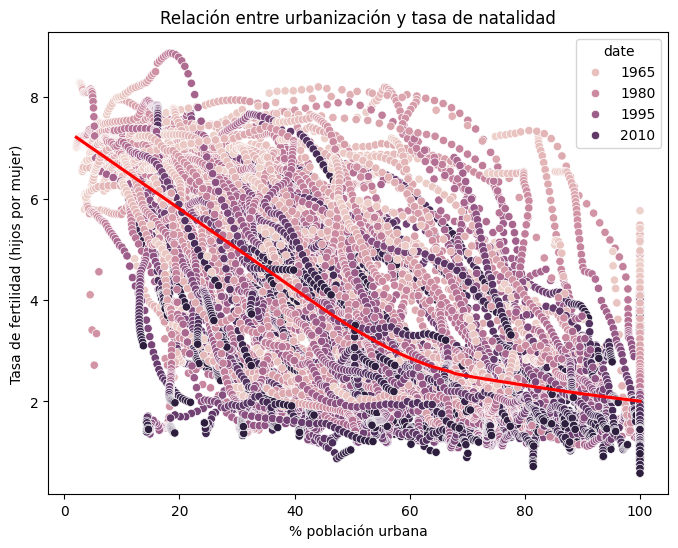

In [65]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pivot,
    x="urban_rate", 
    y="SP.DYN.TFRT.IN", 
    hue='date',
)
sns.regplot(data=df_pivot, x="urban_rate", y="SP.DYN.TFRT.IN", lowess=True, scatter=False, line_kws={'color': 'red'})
plt.title("Relación entre urbanización y tasa de natalidad")
plt.xlabel("% población urbana")
plt.ylabel("Tasa de fertilidad (hijos por mujer)")

plt.show()


En este primer grafico se puede observar que alrededor de 1965 la tasa de fertilidad es alta (aproximadamente 5-7 hijos por mujer) y su porcentaje de poblacion urbana es aproximadamente menor al 40%. Tambien, se logra observar que mientras pasan los años la tasa de fertilidad va disminuyendo (llegando aproximadamente 2-4 hijos por mujer en 2010) y a su vez, el porcentaje de poblacion urbana va creciendo.

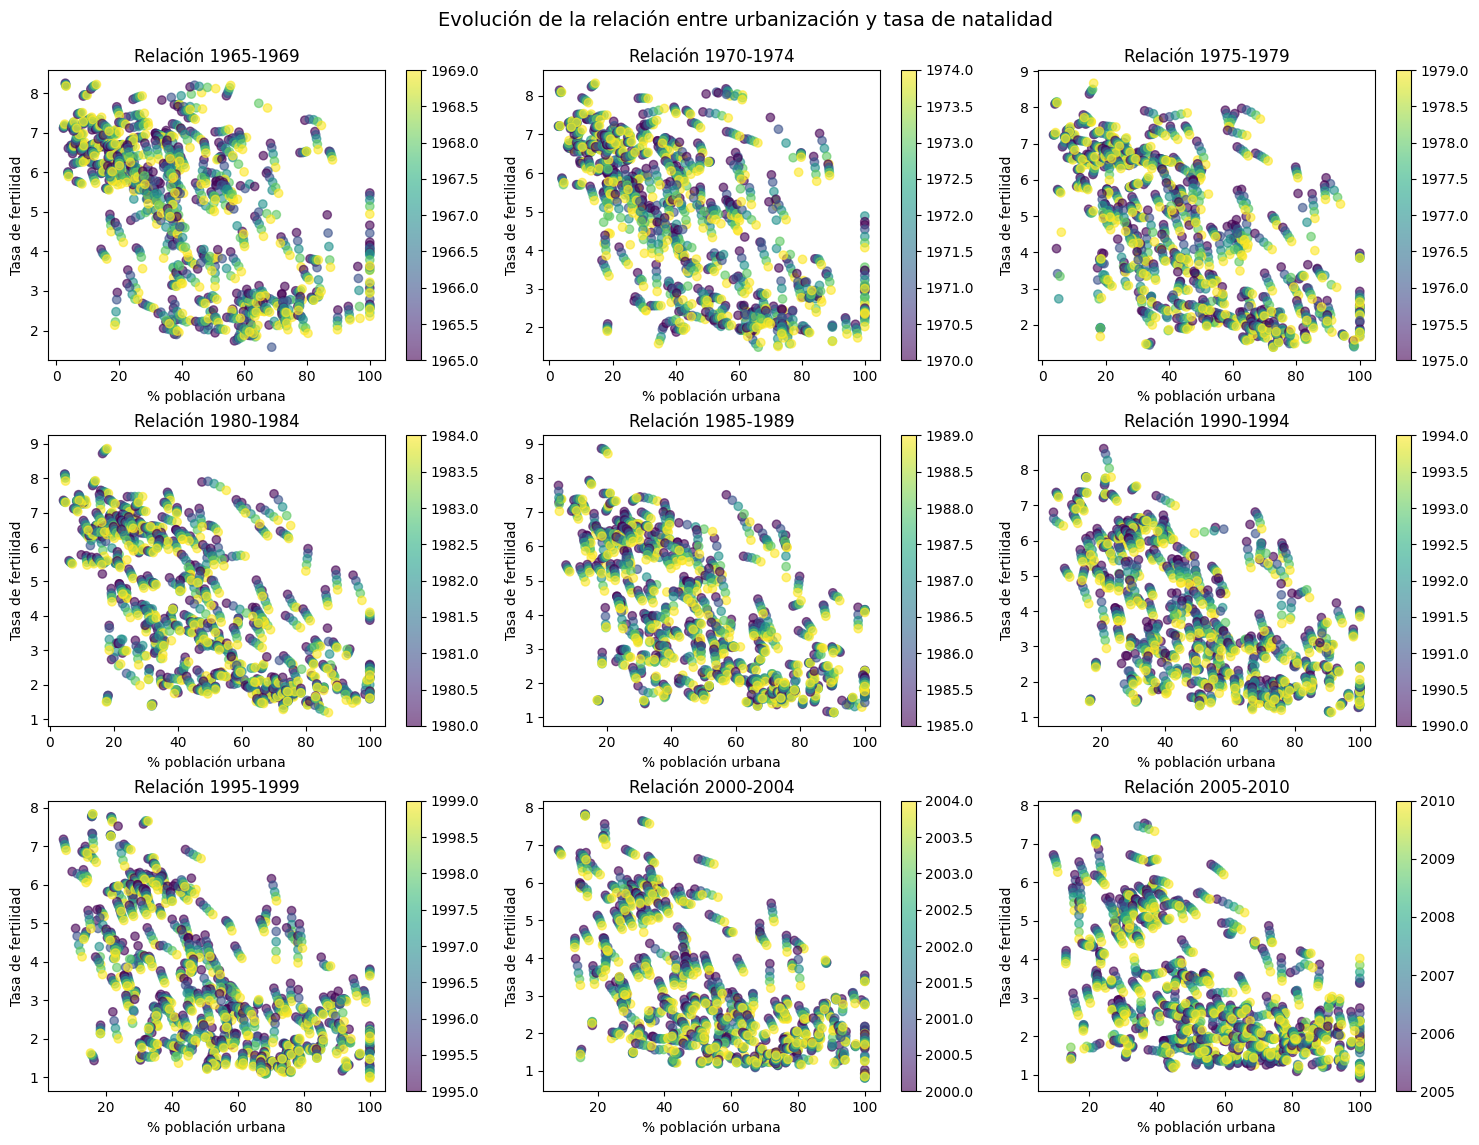

In [66]:
## Posible alternativa de varios graficos dividos en una matriz 3x3.
# 1) Desconozco si los datos realmente llegan desde 1965 al 2010
# 1.1) En caso de ser necesario los rangos pueden ajustarse modificando la lista de tuplas: "year_range"
# 2) No ha sido probado ya que no tengo tiempo de descargar los datos, al tiempo de realizar este commit.

# Crear rangos de años de 5 en 5
year_ranges = [
    (1965, 1969),
    (1970, 1974),
    (1975, 1979),
    (1980, 1984),
    (1985, 1989),
    (1990, 1994),
    (1995, 1999),
    (2000, 2004),
    (2005, 2010)
]

# Crear figura con subgráficos
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # Aplanar para iterar fácilmente

for idx, (start_year, end_year) in enumerate(year_ranges):

    # Filtrar datos para el rango de años actual
    mask = (df_pivot['date'] >= start_year) & (df_pivot['date'] <= end_year)
    df_range = df_pivot.loc[mask]
    
    # Crear scatter plot en el subgráfico correspondiente
    sc = axes[idx].scatter(
        x=df_range["urban_rate"],
        y=df_range["SP.DYN.TFRT.IN"],
        c=df_range["date"],
        cmap="viridis",
        alpha=0.6
    )
    
    # Añadir una colorbar individual para cada subgráfico
    plt.colorbar(sc, ax=axes[idx])
    
    axes[idx].set_title(f"Relación {start_year}-{end_year}")
    axes[idx].set_xlabel("% población urbana")
    axes[idx].set_ylabel("Tasa de fertilidad")

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle("Evolución de la relación entre urbanización y tasa de natalidad", fontsize=14, y=0.95)
plt.show()

Ahora, teniendo las fechas dividas en distintos graficos se puede observar que entre 1965-1975 la mayoria de los puntos se encuentran en el rango de alta fertilidad (5-8 hijos por mujer) y que hay un bajo nivel de urbanizacion (aproximadamente menor al 50%), mientras que en años como 1980 hasta 1995, estos puntos avanzan a un mayor porcentaje de urbanizacion y que a su vez se va disminuyendo la tasa de fertilidad. Ya estando entre 2000-2010, se observa que la mayoria de los puntos tienen una muy baja tasa de fertilidad, estando la mayoria de puntos por debajo de 3 hijos por mujer y ademas teniendo un porcentaje de poblacion urbana aproximadamente mayor al 60%. Esto nos da una vision mas detallada a lo que pasa en cada año, dejando a ver que mientras pasan los años es mayor el porcentaje de poblacion urbana y a su vez menor es la tasa de fertilidad, confirmandonos las suposiciones que hicimos en el primer grafico.

## Conclusiones preliminares

Viendo los resultados, nos damos cuenta que el aumento de porcentaje de poblacion urbana esta asociado a la baja tasa de fertilidad. Se puede ver que mientras pasan los años (1965 hasta 2010) el porcentaje de poblacion urbana aumenta y la tasa de fertilidad va disminuyendo. Esto se puede deber a que antiguamente no habia tanto acceso a la salud, educacion sexual y metodos anticonceptivos, mientras que en la actualidad hay mucha mas informacion sobre esos topicos.

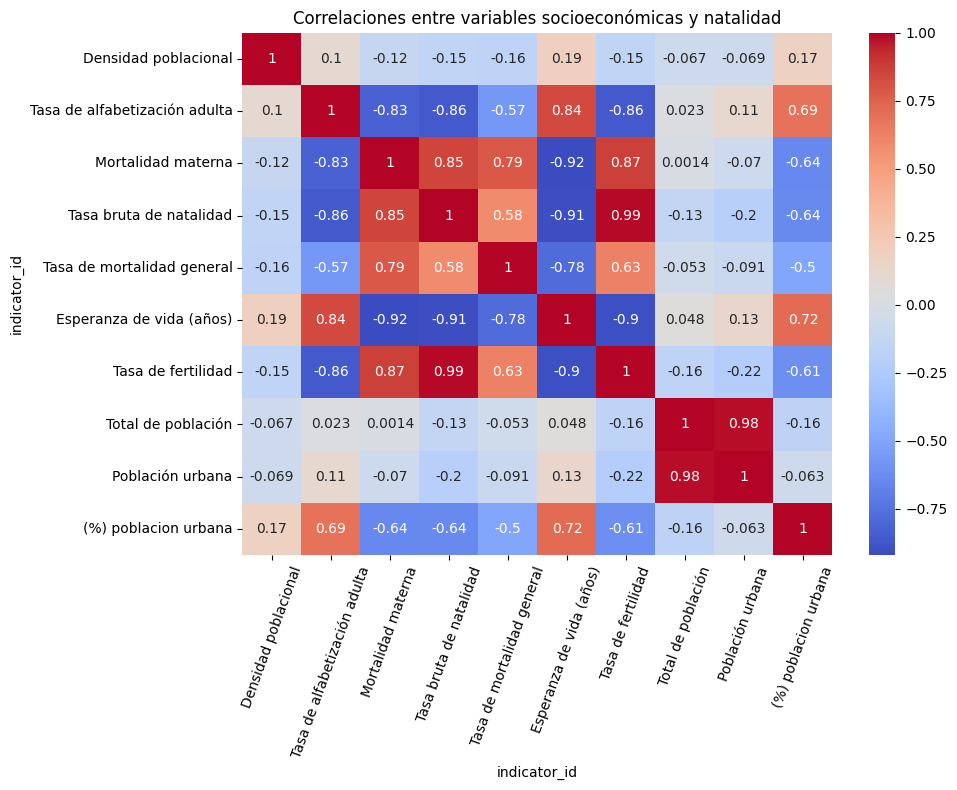

In [67]:
df_pivot2 = df_total.pivot_table(
    index=["country.value", "date"],
    columns="indicator_id",
    values="value"
).reset_index()

# Calcular nivel de urbanización (% de población urbana)
df_pivot2["urban_rate"] = (df_pivot2["SP.URB.TOTL"] / df_pivot2["SP.POP.TOTL"]) * 100

# Se renombran las columnas para facilitar la lectura y visualizacion de datos
df_pivot2 = df_pivot2.rename(columns={'EN.POP.DNST': 'Densidad poblacional', 'SE.ADT.LITR.ZS': 'Tasa de alfabetización adulta',
                                    'SH.STA.MMRT': 'Mortalidad materna', 'SP.DYN.CBRT.IN': 'Tasa bruta de natalidad',
                                    'SP.DYN.CDRT.IN': 'Tasa de mortalidad general', 'SP.DYN.LE00.IN': 'Esperanza de vida (años)',
                                    'SP.DYN.TFRT.IN': 'Tasa de fertilidad', 'SP.POP.TOTL': 'Total de población',
                                    'SP.URB.TOTL': 'Población urbana', 'urban_rate': '(%) poblacion urbana'})
numeric_df = df_pivot2.drop(columns=['country.value', "date"]).dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlaciones entre variables socioeconómicas y natalidad")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


Se puede ver que la Tasa de alfabetizacion adulta y esperanza de vida tiene una relacion negativa respecto a la tasa de fertilidad y mortalidad materna, diciendo que a mayor alfabetizacion adulta o esperanza de vida, menor es la tasa de fertilidad y mortalidad materna, esto nos indica que los paises que tienen una alta educacion y esperanza de vida tienden a tener menos hijos y por consecuencia menos muertes por maternidad. 

Tambien se puede ver la alta relacion entre la Tasa bruta de natalidad y la Tasa de fertilidad (lo cual es esperable), pero tambien hay una preocupante relacion entre la tasa de fertilidad y la mortalidad materna indicando que en paises donde nacen mas hijos por mujer , mayores son las probabilidades de muerte para las madres.

Por ultimo, se puede ver que no hay ninguna relacion entre el total de poblacion y los demas indicadores, dado que si un pais tiene muchos o pocos habitantes, esto no influye a la tasa de alfabetizacion, tasa de fertilidad o esperanza de vida ya que un pais puede tener muchos habitantes y tener la misma tasa de alfabetizacion que un pais que tiene pocos habitantes.

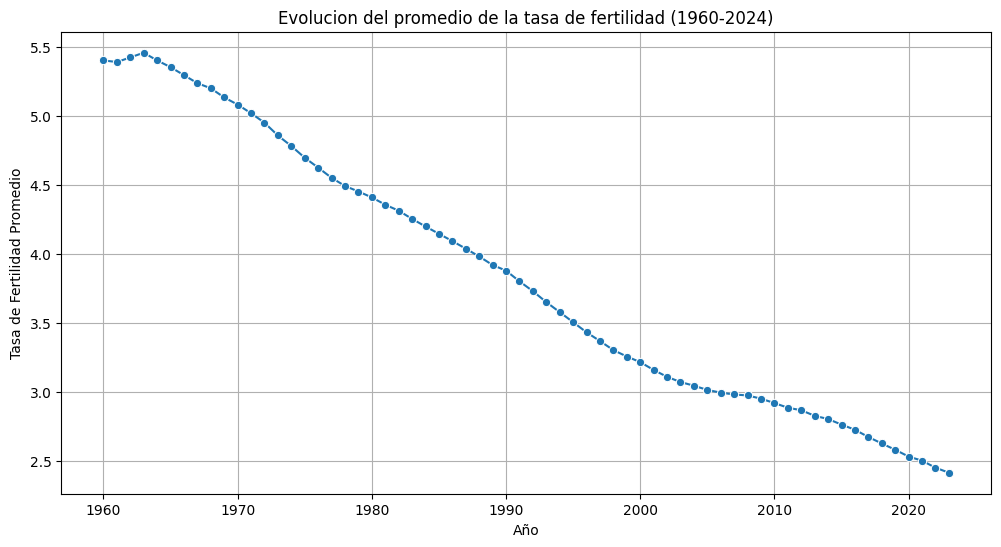

In [68]:
df_temp = df_pivot2.groupby('date')['Tasa de fertilidad'].mean().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(data=df_temp, x='date', y='Tasa de fertilidad', marker='o')
plt.title("Evolucion del promedio de la tasa de fertilidad (1960-2024)")
plt.xlabel("Año")
plt.ylabel("Tasa de Fertilidad Promedio")
plt.grid(True)

plt.show()

Se puede observar que en 1960 el promedio la Tasa de Fertilidad Promedio es aproximadamente 5.5 hijos por mujer y segun pasan los años, la Tasa de Fertilidad Promedio baja constantemente (sin ninguna subida notable), llegando en 2024 a un poco menos de la mitad de hijos por mujer que se tenian en 1960. Esto se puede relacionar a lo que se vio en el heatmap que mientras mayor alfabetizacion adulta haya, menor va a hacer la tasa de fertilidad, y si analizamos el grafico, este nos dice indirectamente que la alfabetizacion adulta global ha ido en aumento, y por consecuencia la tasa de fertilidad ha ido en bajada.

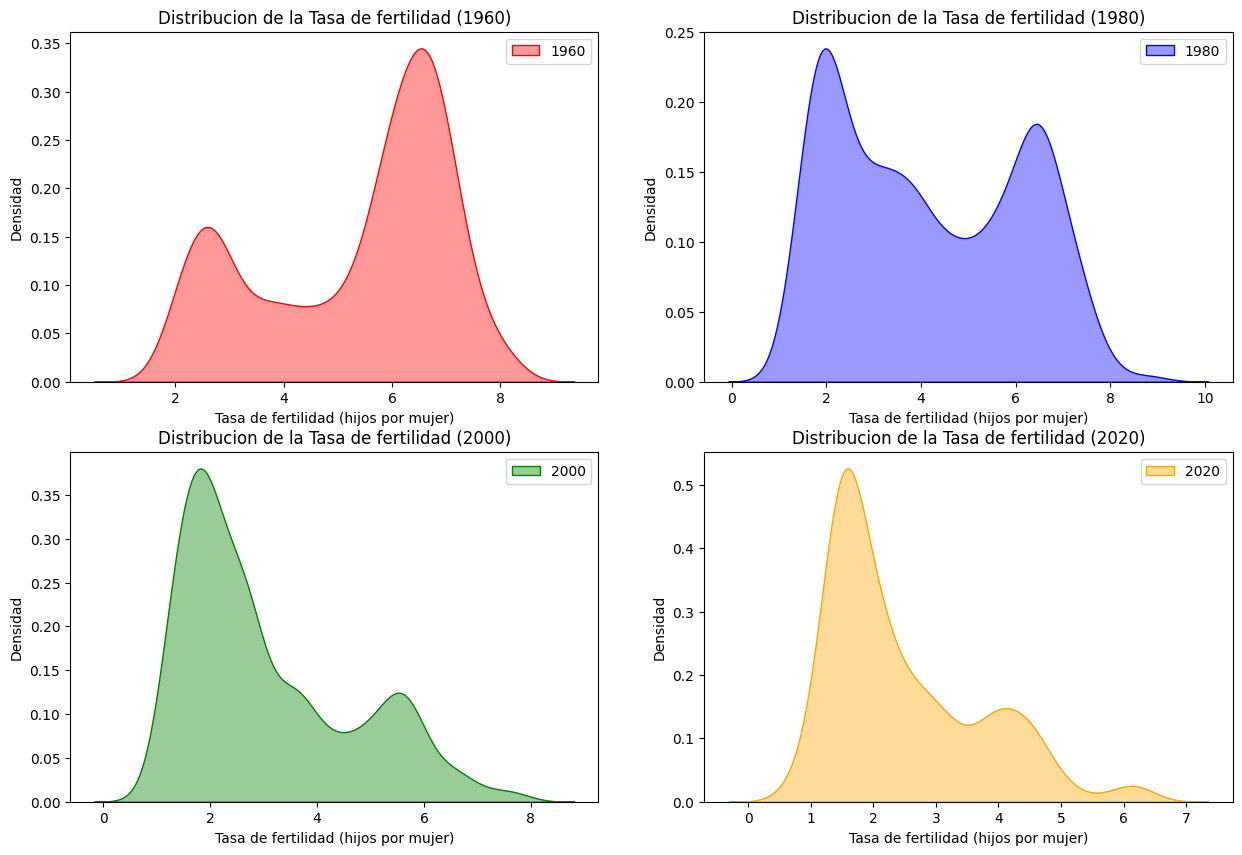

In [69]:
df_pivot2['decada'] = (df_pivot2['date'] // 10) * 10

colors = ['red', 'blue', 'green', 'orange']

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax = ax.flatten()

for i, anio in enumerate([1960, 1980, 2000, 2020]):
    sns.kdeplot(data=df_pivot2[df_pivot2['decada'].isin([anio])], x="Tasa de fertilidad", fill=True, alpha=0.4, ax=ax[i], hue=anio, palette=[colors[i]])
    ax[i].set_title(f"Distribucion de la Tasa de fertilidad ({anio})")
    ax[i].set_xlabel("Tasa de fertilidad (hijos por mujer)")
    ax[i].set_ylabel("Densidad")

plt.show()

En estos graficos se vuelve a confirmar que hay una transicion en la Tasa de fertilidad, pasando de mucha fertilidad a poca fertilidad. Se puede ver en el grafico de la decada de 1960 que la densidad de la Tasa de fertilidad se concentra mayormente entre 6-7 hijos por mujer, pero tambien hay una densidad menor entre 2-3 hijos por mujer. En la decada de 1980, ya se empieza a ver una pequeña transicion de la Tasa de fertilidad ya que esta ahora esta muy bien distribuida estando mayormente entre 2-4 hijos por mujer, pero tambien habiendo una importante densidad entre 6-7 hijos por mujer. En la decada de los 2000, ya se ve que la densidad de la Tasa de fertilidad esta mayormente entre 1-3 hijos por mujer, pero todavia habiendo una pequeña densidad entre 5-6 hijos por mujer. Por ultimo, en la decada de 2020, ya se ve una distribucion en la Tasa de fertilidad bastante desequilibrada, estando un poco mas de la mitad de la densidad entre 1-2 hijos por mujer, donde tener 6-7 hijos por mujer ya es raro a comparacion de lo normal que era en la decada de 1960.

Los paises que son outliers son: ['American Samoa' 'Antigua and Barbuda' 'Bahrain' 'British Virgin Islands'
 'China' 'Djibouti' 'Iraq' 'Jordan' 'Kuwait' 'Libya' 'Liechtenstein'
 'Nepal' 'Northern Mariana Islands' 'Qatar' 'Saudi Arabia' 'Singapore'
 'Sri Lanka' 'St. Lucia' 'Thailand' 'United Arab Emirates' 'Viet Nam'
 'West Bank and Gaza']


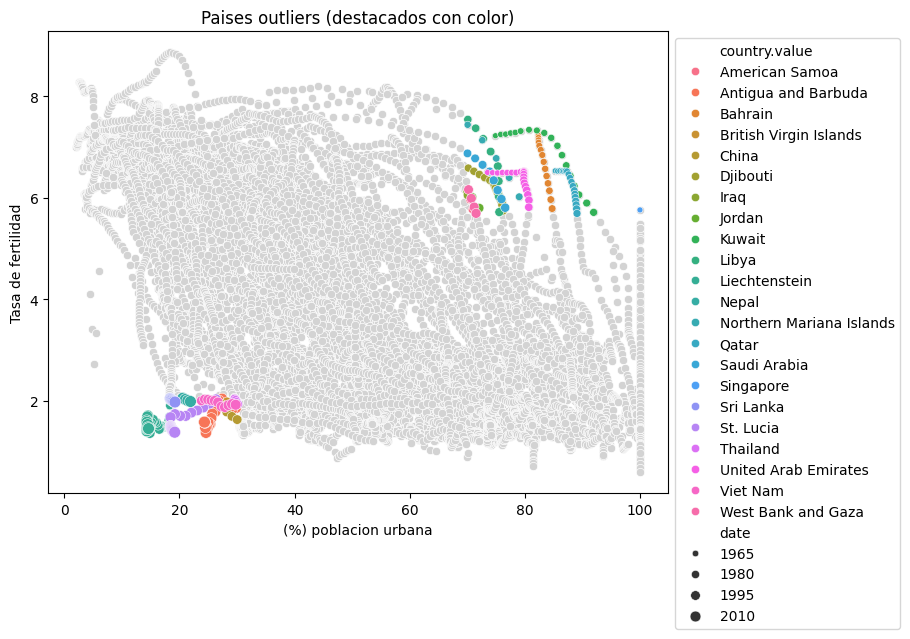

In [70]:
Q1_urban_rate = df_pivot2['(%) poblacion urbana'].quantile(0.25)
Q3_urban_rate = df_pivot2['(%) poblacion urbana'].quantile(0.75)

Q1_fertilidad = df_pivot2['Tasa de fertilidad'].quantile(0.25)
Q3_fertilidad = df_pivot2['Tasa de fertilidad'].quantile(0.75)

outliers = df_pivot2[((df_pivot2['(%) poblacion urbana'] < Q1_urban_rate) & (df_pivot2['Tasa de fertilidad'] < Q1_fertilidad)) |
                     ((df_pivot2['(%) poblacion urbana'] > Q3_urban_rate) & (df_pivot2['Tasa de fertilidad'] > Q3_fertilidad))]

print("Los paises que son outliers son:", outliers['country.value'].unique())

plt.figure(figsize=(8, 6))

sns.scatterplot(data=df_pivot2, x='(%) poblacion urbana', y='Tasa de fertilidad', color='lightgray')

sns.scatterplot(data=outliers, x='(%) poblacion urbana', y='Tasa de fertilidad', hue='country.value', size='date')
plt.title("Paises outliers (destacados con color)")
plt.legend(bbox_to_anchor=(1, 1))

plt.show()

Como se logra observar, tambien hay paises que tienen bajo porcentaje de poblacion urbana y baja tasa de fertilidad, como tambien paises con alto porcentaje de poblacion urbana y alta tasas de nataliad (que estan destacados con colores), y a estos los llamamos outliers ya que son paises que no siguen el "patron" general que siguen los demas paises. Se puede ver que los paises con poco porcentaje de urbanizacion y poca fertilidad aparecen entre los años 1995-2010, lo que puede implicar que en esos paises hay mucha poblacion campesina y una gran educacion o pueden haber leyes que restringan la cantidad de hijos que se pueden tener por mujer. 

Por otro lado, se puede ver que en los paises con alto porcentaje de urbanizacion y alta fertilidad aparecen entre los años 1965 y 1980, lo que puede indicar que hubo mucha riqueza en esos paises (probablemente por explotacion de recursos escasos en esos tiempos) pero poca educacion, lo que hace que estos paises esten altamente urbanizados y con grandes familias, pero sin ninguna educacion buena a comparacion con otros paises con altos porcentajes de urbanizacion y poca tasa de fertilidad.

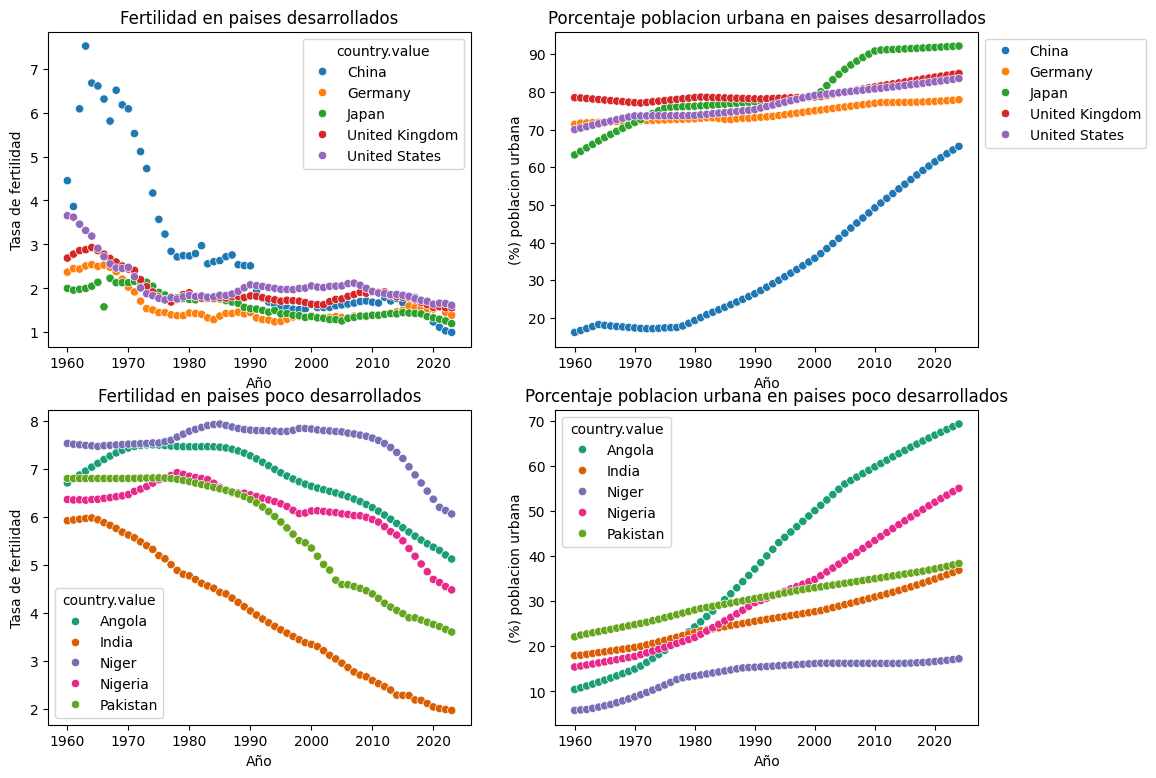

In [71]:
paises_importantes = ['United States', 'China', 'Japan', 'United Kingdom', 'Germany']
paises_poco_desarrollados = ['India', 'Niger', 'Pakistan', 'Nigeria', 'Angola']

df_paises_avanzados = df_pivot2[df_pivot2['country.value'].isin(paises_importantes)]

df_paises_poco_desarrollados = df_pivot2[df_pivot2['country.value'].isin(paises_poco_desarrollados)]


fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

sns.scatterplot(data=df_paises_avanzados, ax=axes[0], x='date', y='Tasa de fertilidad', hue='country.value')
axes[0].set_title("Fertilidad en paises desarrollados")
axes[0].set_xlabel("Año")

sns.scatterplot(data=df_paises_avanzados, ax=axes[1], x='date', y='(%) poblacion urbana', hue='country.value')
axes[1].set_title("Porcentaje poblacion urbana en paises desarrollados")
axes[1].set_xlabel("Año")
axes[1].legend(bbox_to_anchor=(1, 1))

sns.scatterplot(data=df_paises_poco_desarrollados, ax=axes[2], x='date', y='Tasa de fertilidad', hue='country.value', palette='Dark2')
axes[2].set_title("Fertilidad en paises poco desarrollados")
axes[2].set_xlabel("Año")

sns.scatterplot(data=df_paises_poco_desarrollados, ax=axes[3], x='date', y='(%) poblacion urbana', hue='country.value', palette='Dark2')
axes[3].set_title("Porcentaje poblacion urbana en paises poco desarrollados")
axes[3].set_xlabel("Año")

plt.show()


Aunque en los analisis anteriores hemos visto que en los ultimos años, la tasa de fertilidad se encuentra entre 1-2 hijos por mujer, esto no siempre es asi en todos los paises. Se puede ver que en paises "mas desarrollados" la tasa de fertilidad siempre se ha mantenido relativamente baja excepto en China que en 1960 tenia una alta tasa de fertilidad donde fue disminuyendo con los años, y una de las razones de porque esto sucede es que como se logra observar en el grafico de arriba a la derecha, estos paises ya tenian un porcentaje de poblacion urbana muy alto (entre 65% y 80%), lo que implica que ya estaban altamente desarrollados en esos años respecto a otros paises, tambien se puede ver que China empezo con poco porcentaje de poblacion urbana en 1960 (y puede ser una de las razones por las cual tambien tiene alta fertilidad en 1960) y fue creciendo gradualmente con los años. 

Por otra parte, los paises "menos desarrollados" se puede ver que al principio tenian tasas de fertilidad muy altas llegando unos paises a casi 8 hijos por mujer, pero aunque estos paises han disminuido igualmente sus tasas de fertilidad, estos aun tiene altas tasas de fertilidad en la mayoria de casos. Si observamos el grafico de abajo a la derecha, los paises "poco desarrollados" tenian poco porcentaje de poblacion urbana (entre 5% y 25%) en 1960 a comparacion de los paises "desarrollados", lo que confirma una de las razones del porque hay alta fertilidad en ese año es porque no habia tanta urbanizacion en esos paises.

### Pairplot general

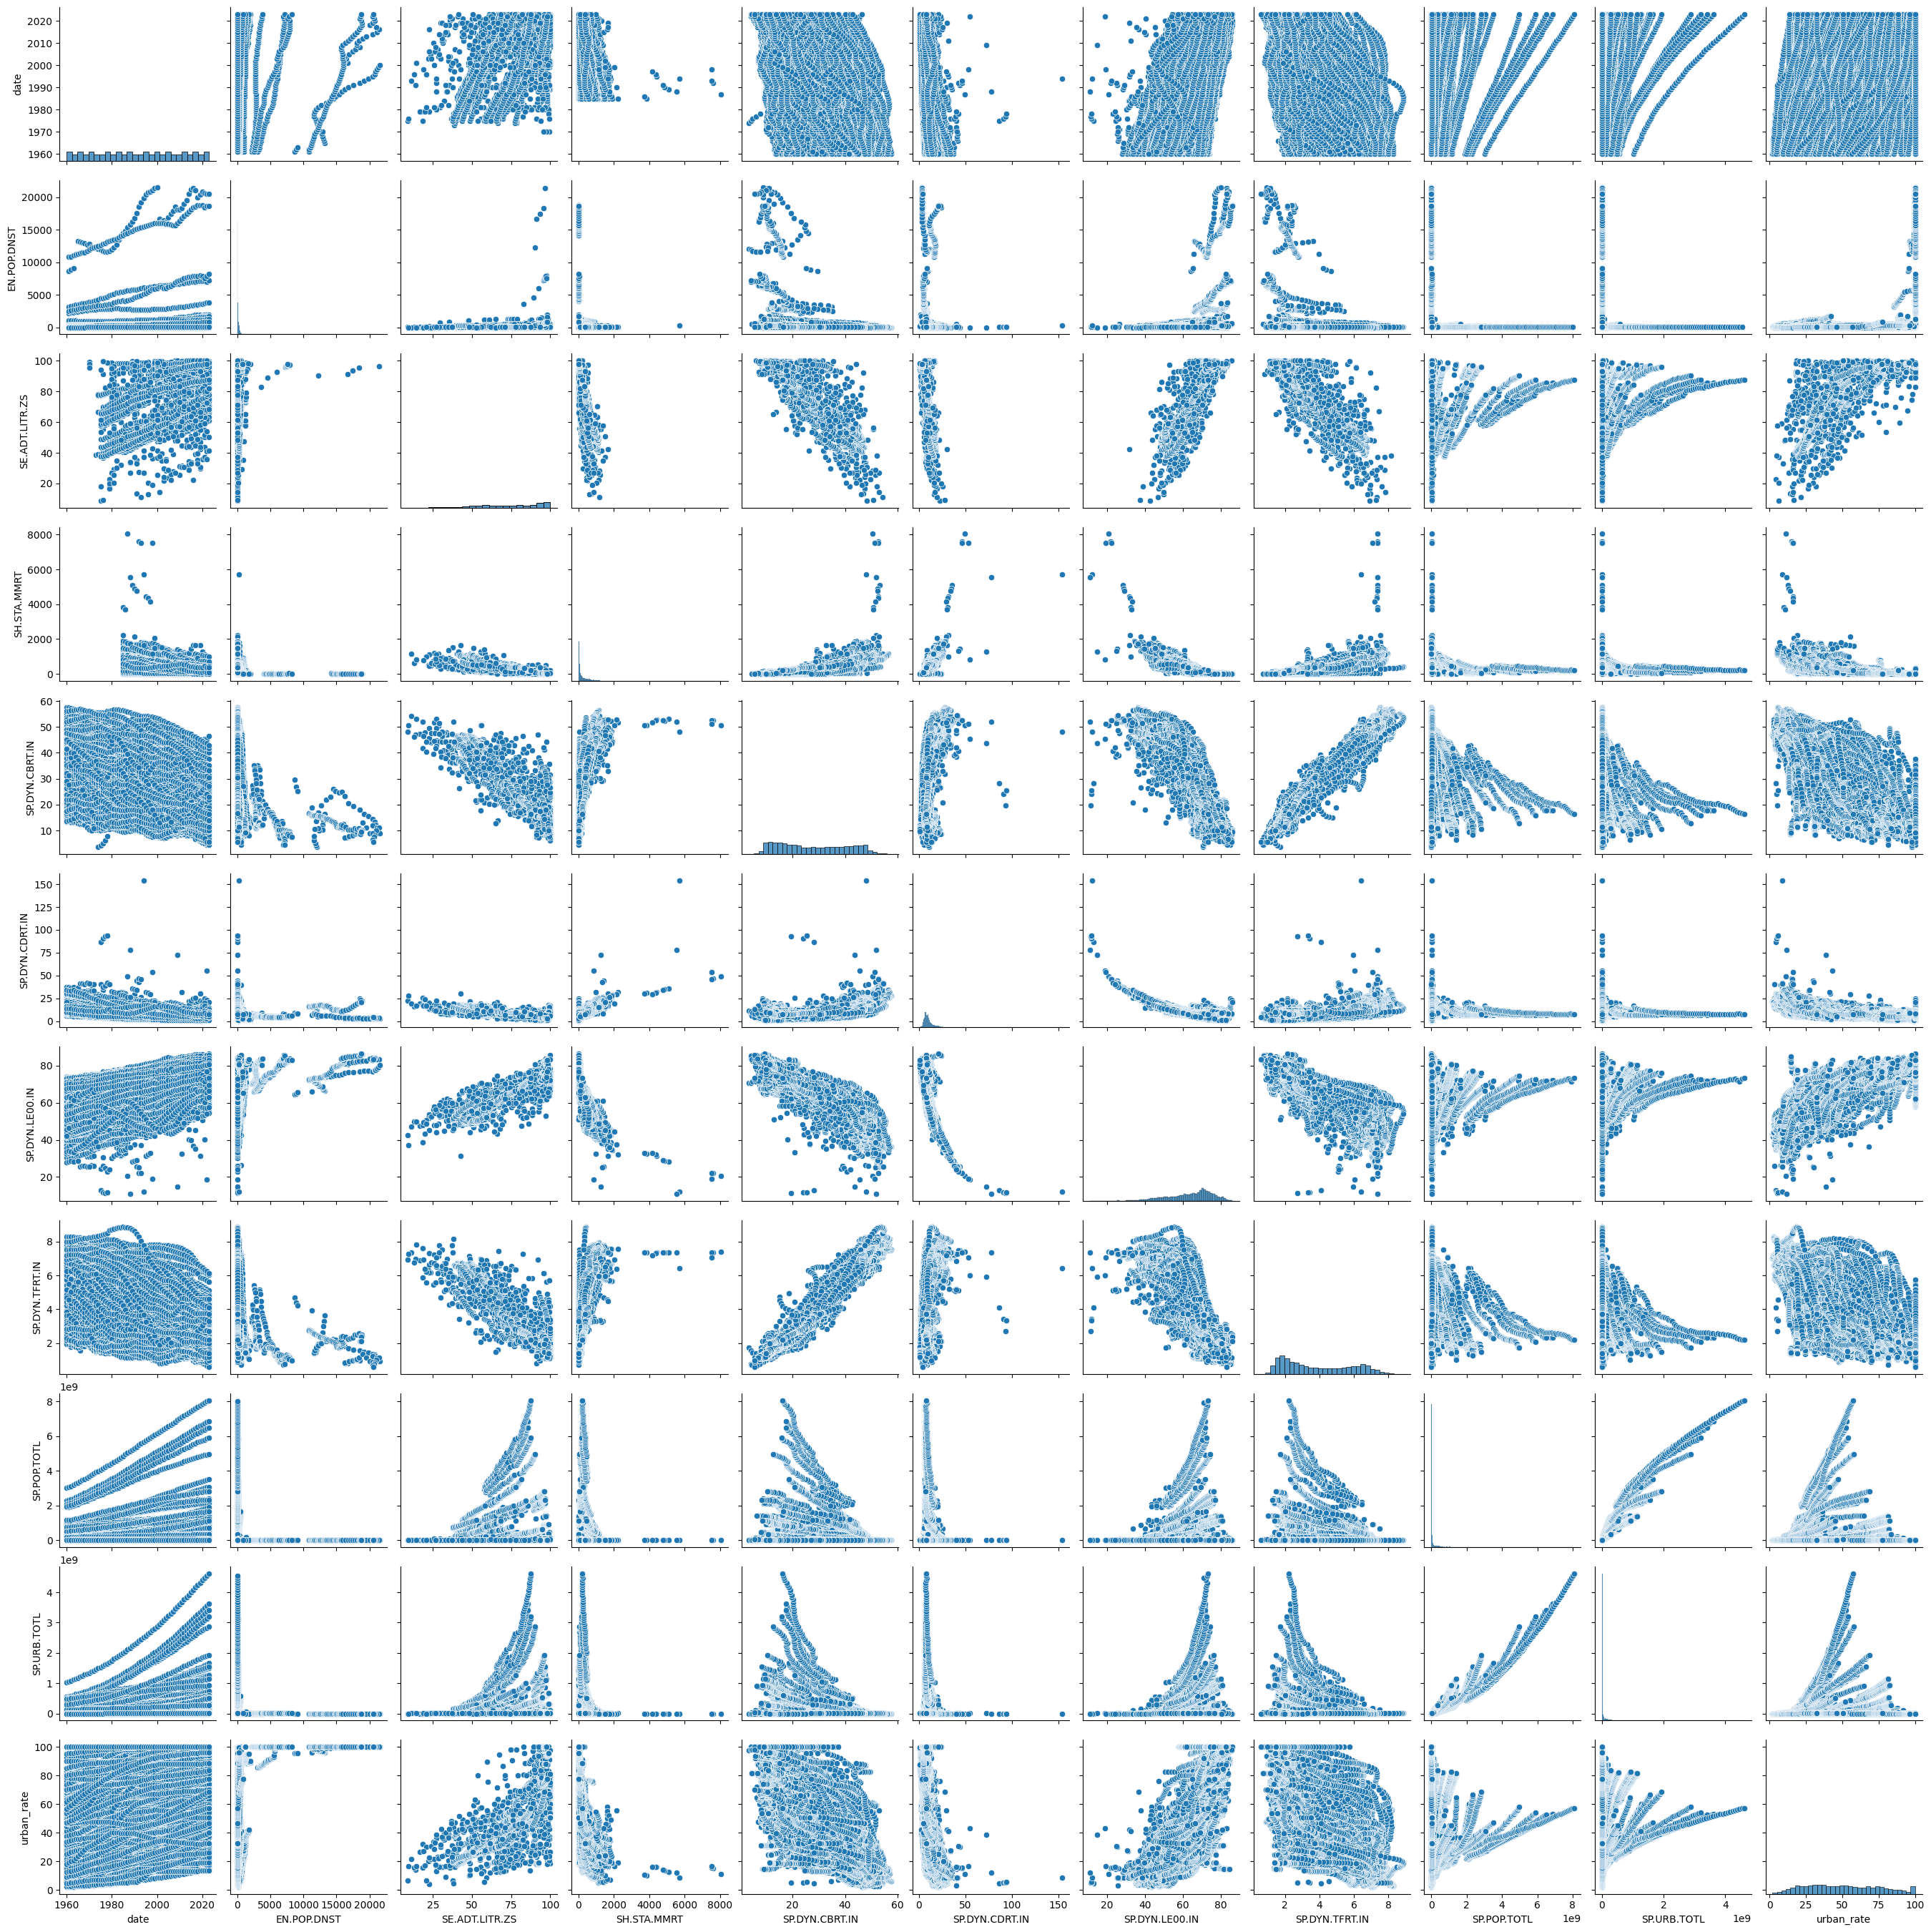

In [72]:
sns.pairplot(df_pivot)
plt.show()


In [73]:
paises_mapeo = {
    'United States': 'United States of America',
    'Congo, Dem. Rep.': 'Dem. Rep. Congo',
    'Congo, Rep.': 'Congo',
    "Cote d'Ivoire": "Côte d'Ivoire",
    'Eswatini': 'eSwatini',
    'Solomon Islands': 'Solomon Is.',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Lao PDR': 'Laos',
    'Viet Nam': 'Vietnam',
    'Brunei Darussalam': 'Brunei',
    'Egypt, Arab Rep.': 'Egypt',
    'Gambia, The': 'Gambia',
    'Bahamas, The': 'Bahamas',
    'Iran, Islamic Rep.': 'Iran',
    'Russian Federation': 'Russia',
    'Syrian Arab Republic': 'Syria',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen',
    'Korea, Rep.': 'South Korea',
    "Korea, Dem. People's Rep.": 'North Korea',
    "Hong Kong SAR, China": 'China',
    'Macao SAR, China': 'China',
    'China': 'China',
    'Bosnia and Herzegovina': 'Bosnia and Herz.',
    'Turkiye': 'Turkey',
    'Faroe Islands': 'Denmark', 'Greenland': 'Denmark',
    'Puerto Rico (US)': 'Puerto Rico',
    'Channel Islands': 'United Kingdom', 'Isle of Man': 'United Kingdom', 'Gibraltar': 'United Kingdom',
}

## Creacion GeoDataFrame

In [74]:
# 1. Load data
df_w = df_pivot2.copy()
mundo = gpd.read_file('ne_110m_admin_0_countries.shp')
mundo = mundo[['NAME', 'geometry']]

data = df_w.sort_values('date').groupby('country.value').last().reset_index()

data['country_mapped'] = data['country.value'].map(paises_mapeo).fillna(data['country.value'])
data = data.drop(columns='country.value')

mundo_datos = mundo.merge(
    data, 
    left_on='NAME',  right_on='country_mapped', 
    how='inner'
)

mundo_datos.sample(1)

,NAME,geometry,date,Densidad poblacional,Tasa de alfabetización adulta,Mortalidad materna,Tasa bruta de natalidad,Tasa de mortalidad general,Esperanza de vida (años),Tasa de fertilidad,Total de población,Población urbana,(%) poblacion urbana,decada,country_mapped
60,Congo,"POLYGON ((18.45307 3.50439, 18.39379 2.90044, ...",2024,18.105081,76.110001,241.0,30.627,6.288,65.772,4.157,6332961.0,4410147.0,69.637994,2020,Congo


### Creacion mapa mundial

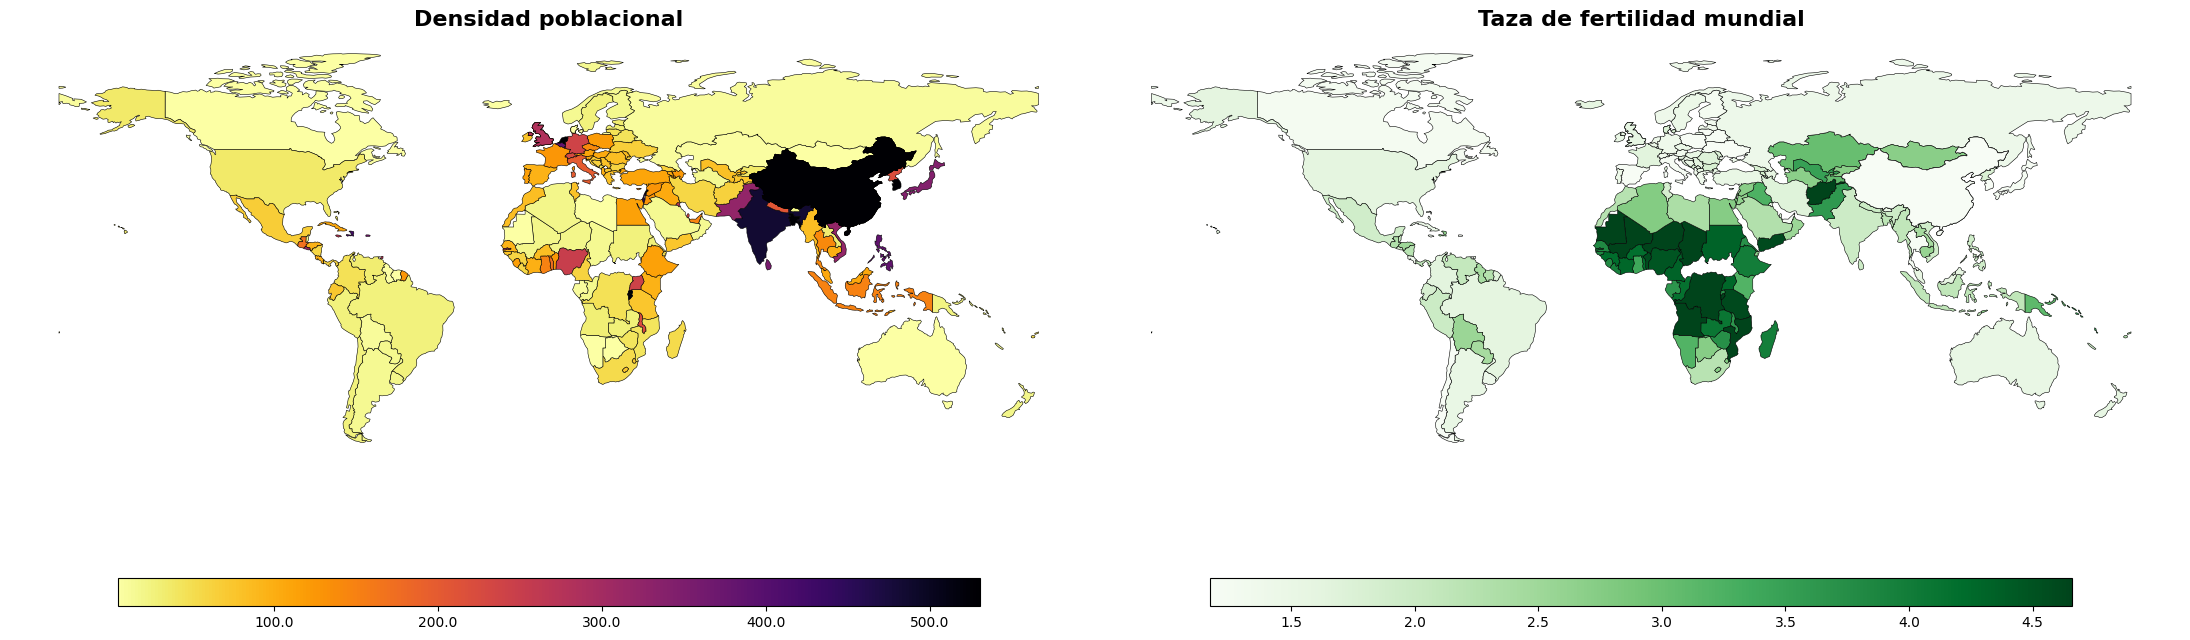

In [75]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

densidad = mundo_datos['Densidad poblacional'].dropna()
fertilidad = mundo_datos['Tasa de fertilidad'].dropna()

d_vmin, d_vmax = densidad.quantile([0.05, 0.95]).values
f_vmin, f_vmax = fertilidad.quantile([0.05, 0.95]).values

mundo_datos.plot(
    column='Densidad poblacional',
    ax=ax1,
    legend=True,
    cmap='inferno_r',
    edgecolor='black', linewidth=0.4,
    vmin=d_vmin, vmax=d_vmax,
    legend_kwds={'orientation': 'horizontal', 'aspect': 30, 'format': '%.1f', 'shrink': 0.8})

mundo_datos.plot(
    column='Tasa de fertilidad',
    ax=ax2,
    legend=True,
    cmap='Greens',
    edgecolor='black',linewidth=0.4,
    vmin=f_vmin, vmax=f_vmax,
    legend_kwds={'orientation': 'horizontal', 'aspect': 30, 'format': '%.1f', 'shrink': 0.8})

ax1.set_title('Densidad poblacional', fontsize=16, fontweight='bold')
ax2.set_title('Taza de fertilidad mundial', fontsize=16, fontweight='bold')
ax1.set_axis_off()
ax2.set_axis_off()
plt.tight_layout()
plt.savefig('grafico.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Modelos de Machine Learning

In [76]:
df_machine = df_pivot2.drop(columns=[
    "Tasa de alfabetización adulta",
    "Mortalidad materna",
    "country.value"
]) #A pesar de tener buenos datos estas columnas estan inusables con tantos Nan y country value no sirve, ya que solo es el nombre del pais
df_machine = df_machine.dropna()

In [77]:

# Variable objetivo (tasa de natalidad)
y = df_machine["Tasa de fertilidad"]

# Variables predictoras (todas las demás)
X = df_machine.drop(columns=["Tasa bruta de natalidad", "Tasa de fertilidad"]) 
#a pesar que natalidad es un gran dato es literalmente darle la respuesta al modelo


In [78]:
df_machine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15280 entries, 1 to 17198
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        15280 non-null  int64  
 1   Densidad poblacional        15280 non-null  float64
 2   Tasa bruta de natalidad     15280 non-null  float64
 3   Tasa de mortalidad general  15280 non-null  float64
 4   Esperanza de vida (años)    15280 non-null  float64
 5   Tasa de fertilidad          15280 non-null  float64
 6   Total de población          15280 non-null  float64
 7   Población urbana            15280 non-null  float64
 8   (%) poblacion urbana        15280 non-null  float64
 9   decada                      15280 non-null  int64  
dtypes: float64(8), int64(2)
memory usage: 1.3 MB


In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) #separamos los valores entr test y train
scaler = StandardScaler() #creamos un escalador y lo aplicamos a X, ya que son muchas variables que varian mucho (como edad o pais)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

***Modelo: KNN Regressor***
MAE:  0.3832252202298278
RMSE:  0.3206941612971574
r^2:  0.9168685773346958



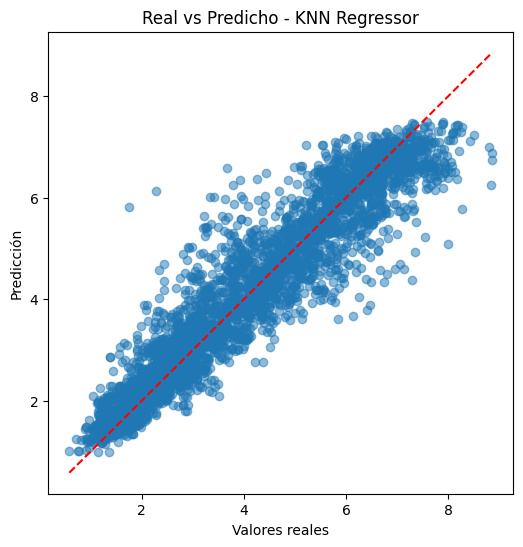

--------------------------------
***Modelo: Decision Tree Regressor***
MAE:  0.3497770210543043
RMSE:  0.30403422571450206
r^2:  0.9211872220549381



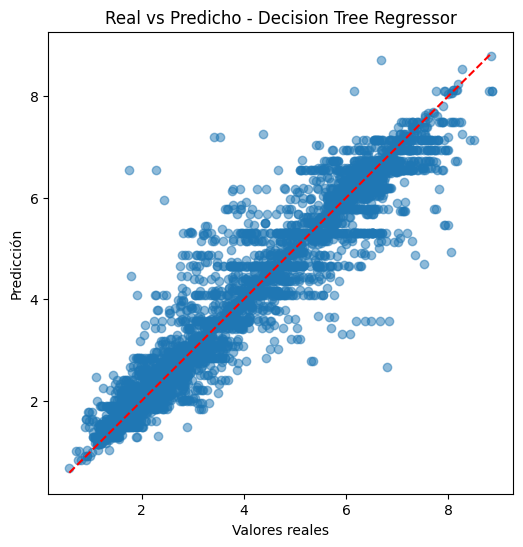

--------------------------------
***Modelo: Lasso Regression***
MAE:  0.6933898571070973
RMSE:  0.8145987259055691
r^2:  0.7888369694291832



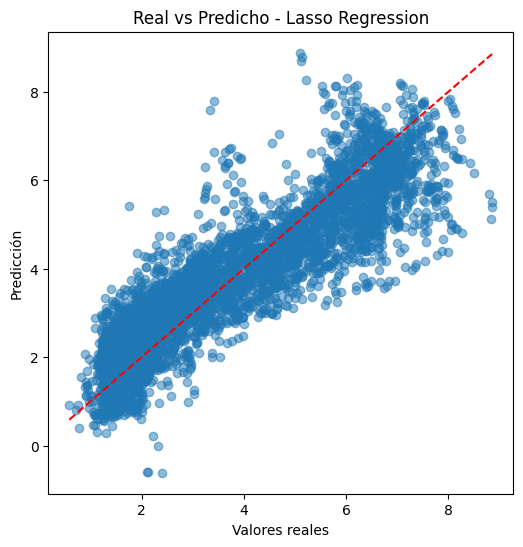

--------------------------------
***Modelo: Random Forest Regressor***
MAE:  0.24679637270649754
RMSE:  0.15045897911588138
r^2:  0.9609975157137874



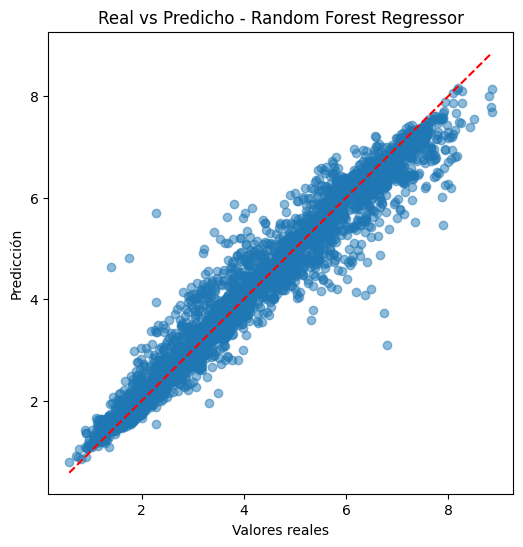

--------------------------------


In [80]:
resultados = []
#diccionario de modelos (mas bonito para hacer cada modelo)
modelos = {
    "KNN Regressor": KNeighborsRegressor(n_neighbors=10),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Lasso Regression": Lasso(alpha=0.05, random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
}

for mode in modelos.keys():
    modelos[mode].fit(X_train_scaled, y_train)
    y_pred = modelos[mode].predict(X_test_scaled)

    #Las metricas de cada modelo
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    resultados.append({mode: [mae, rmse, r2]})
    print (f"***Modelo: {mode}***")
    print ("MAE: ", mae)
    print ("RMSE: ", rmse)
    print ("r^2: ", r2)
    print ("")
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Valores reales")
    plt.ylabel("Predicción")
    plt.title(f"Real vs Predicho - {mode}")
    plt.show()
    print ("--------------------------------")



En general, todos los modelos evaluados muestran un rendimiento muy alto (r^2 mayores que 0.90 a excepcion de lasso), lo que indica que las variables utilizadas explican gran parte de la variabilidad del objetivo; sin embargo, el Random Forest Regressor destaca claramente como el mejor modelo al obtener el MAE más bajo (aprox 0.25), el RMSE más bajo (aprox 0.15) y el r² más alto (aprox 0.96), lo que lo convierte en la opción más robusta y precisa. El KNN Regressor también muestra un buen desempeño, aunque ligeramente inferior, mientras que Decision Tree presenta una precisión aceptable pero con mayor error y más inestable. Finalmente, Lasso Regression es el de menor rendimiento relativo

## Conclusiones finales

Despues de analizar todos estos datos historicos sobre la natalidad de distintos paises, se ha podido confirmar una tendencia de la natalidad con respecto a otras variables como el porcentaje de urbanizacion, esperanza de vida, tasa de alfabetizacion adulta, mortalidad materna, entre otras. Esto se realizo a traves de la exploracion de datos y la aplicacion de modelos de Machine Learning.

Primero, se logro demostrar que hay una clara relacion entre el nivel de urbanizacion y la tasa de natalidad. Los graficos de scatterplots y lineas que se hicieron en la exploracion de datos nos muestran que a medida que la urbanizacion va avanzando, la tasa de fertilidad va disminuyendo. Se puede ver que entre los años de 1960 y 1980 la tasa de fertilidad era muy alta a comparacion de la baja urbanizacion que habia, pero segun fueron pasando los años sus papeles se invirtieron, haciendo que la urbanizacion aumente y la tasa de fertilidad disminuya, indicando que tambien estaba bajando la natalidad.

Despues, se pudo comprobar que hay patrones que explican el porque hay grandes diferencias de natalidad en distintos años. En la exploracion de datos se pudo comprobar que variables socioeconomicas (como el porcentaje de urbanizacion y la tasa de alfabetizacion) son grandes responsables de que haya una baja o alta tasa de fertilidad, ya que mientras avanza la urbanizacion (y a su vez la tasa de alfabetizacion) hay un mayor acceso a la educacion y salud, haciendo que haya un desarrollo social disminuyendo asi la tasa de fertilidad.

Se pudo hacer un modelo que logra predecir la tasa de natalidad de un pais en base a sus condiciones socioeconomicas con una precision muy alta. Se probaron varios modelos de Machine Learning (kNN, Decision Tree, Lasso Regression y Random Forest Regressor) donde Random Forest Regressor demostro ser el modelo mas preciso con un R^2 de aproximadamente 0.96, con el MAE y RMSE mas bajo de todos los modelos.

Tambien, pudimos identificar paises que se comportan como outliers (los que no siguen una tendencia general). Algunos paises outliers son: China, Arabia Saudita, Qatar, Libia, Singapur, entre otros. Estos paises son outliers principalmente por factores especificos, como leyes del paises que limitan tener cierta cantidad de hijos, como el desarrollo economico rapido sin un gran avance al desarrollo social, entre otros factores que hicieron que estos paises "alteraran la tendencia general".

Por ultimo, vimos que en las ultimas decadas hubieron cambios importantes respecto a la tasa de natalidad de los paises, ya que en la decada de 1960 era muy normal que hubiera una tasa de fertilidad entre 6 y 7 hijos por mujer, pero para la decada de 2020, la distribucion de la tasa de fertilidad se "invirtio" completamente, concentrandose la tasa de fertilidad entre 1 y 2 hijos por mujer. Estos cambios se deben principalmente a factores como al aumento de la urbanizacion y desarrollo de un pais donde en la exploracion de los datos se pudo ver que mientras avanza el tiempo, los paises se van desarrollando y por consecuencia hay una bajada en las tasas de fertilidad de estos.

En resumen, estos analisis nos demostraron que el avance y desarrollo de los paises (y sociedades) contribuyen en gran medida a la reduccion de las tasas de natalidad y fertilidad. Vimos que el modelo Random Forest Regressor es la herramienta mas eficaz para estimar las tasas de fertilidad y natalidad de un pais.


In [82]:
# Referencia: https://plotly.com/python/animations/

import plotly.express as px

df_sort = df_pivot2.copy().dropna()
df_sort = df_sort.sort_values(by='date', ascending=True)

# Mapa interactivo 
px.scatter(df_sort, x="(%) poblacion urbana", y="Tasa de fertilidad", animation_frame="date", animation_group="country.value",
           size="Esperanza de vida (años)", color="country.value", hover_name="country.value",
           log_x=True, size_max=25)
